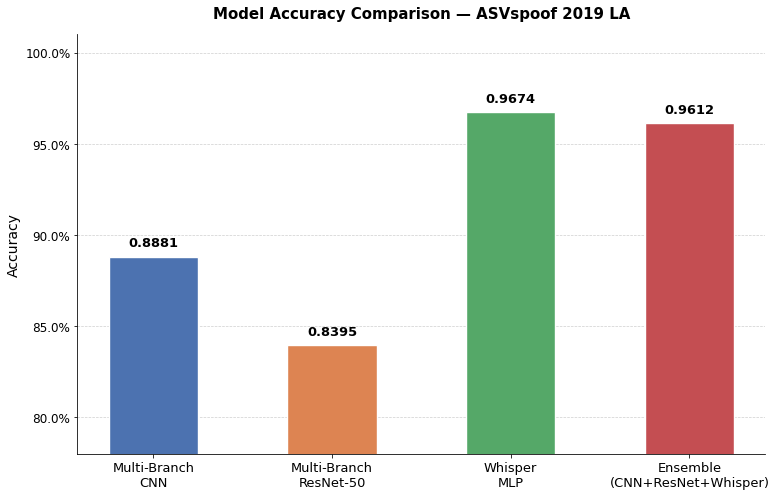

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

names = ['Multi-Branch\nCNN', 'Multi-Branch\nResNet-50', 'Whisper\nMLP', 'Ensemble\n(CNN+ResNet+Whisper)']
accs  = [0.8881, 0.8395, 0.9674, 0.9612]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=1.4, width=0.50, zorder=3)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0.78, 1.01)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Model Accuracy Comparison — ASVspoof 2019 LA', fontsize=15, fontweight='bold', pad=16)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig01_accuracy_bar.png', dpi=300, bbox_inches='tight')
plt.show()

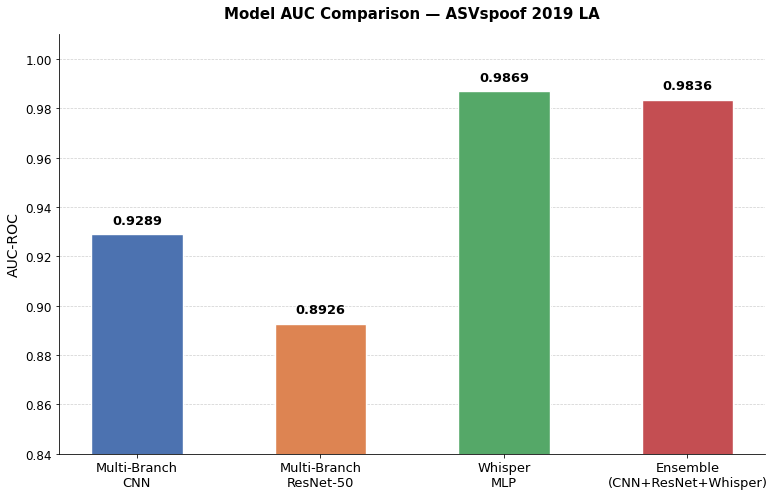

In [2]:
import matplotlib.pyplot as plt

names = ['Multi-Branch\nCNN', 'Multi-Branch\nResNet-50', 'Whisper\nMLP', 'Ensemble\n(CNN+ResNet+Whisper)']
aucs  = [0.9289, 0.8926, 0.9869, 0.9836]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.bar(names, aucs, color=colors, edgecolor='white', linewidth=1.4, width=0.50, zorder=3)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0.84, 1.01)
ax.set_ylabel('AUC-ROC', fontsize=14)
ax.set_title('Model AUC Comparison — ASVspoof 2019 LA', fontsize=15, fontweight='bold', pad=16)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig02_auc_bar.png', dpi=300, bbox_inches='tight')
plt.show()

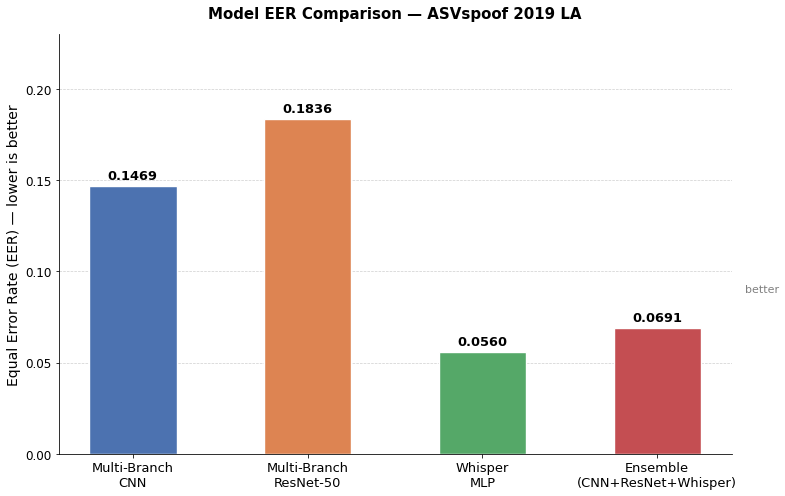

In [3]:
import matplotlib.pyplot as plt

names = ['Multi-Branch\nCNN', 'Multi-Branch\nResNet-50', 'Whisper\nMLP', 'Ensemble\n(CNN+ResNet+Whisper)']
eers  = [0.1469, 0.1836, 0.0560, 0.0691]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.bar(names, eers, color=colors, edgecolor='white', linewidth=1.4, width=0.50, zorder=3)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, eers):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.annotate('', xy=(3.45, 0.02), xytext=(3.45, 0.16),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.8))
ax.text(3.5, 0.09, 'better', color='gray', fontsize=11, va='center')
ax.set_ylim(0, 0.23)
ax.set_ylabel('Equal Error Rate (EER) — lower is better', fontsize=14)
ax.set_title('Model EER Comparison — ASVspoof 2019 LA', fontsize=15, fontweight='bold', pad=16)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig03_eer_bar.png', dpi=300, bbox_inches='tight')
plt.show()

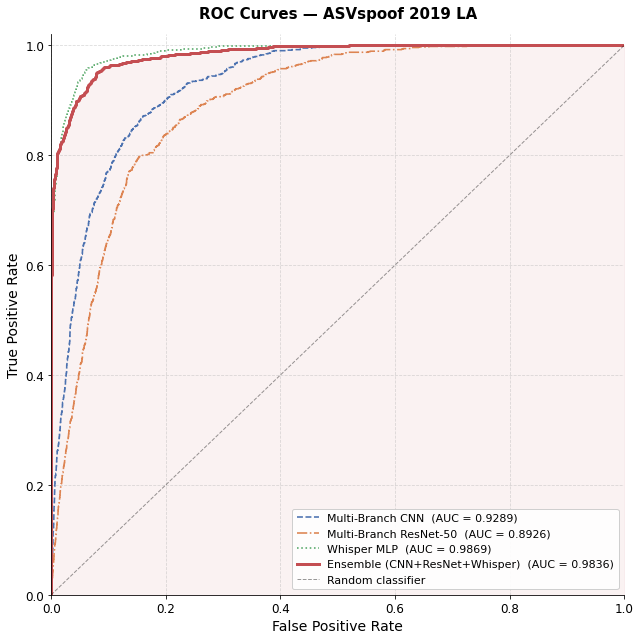

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

cnn_probs    = np.load('saved_models/cnn_file_probs.npy')
cnn_labels   = np.load('saved_models/cnn_file_labels.npy')
resnet_probs = np.load('saved_models/resnet_file_probs.npy')
whisper_probs= np.load('saved_models/whisper_probs.npy')
whisper_lbls = np.load('saved_models/whisper_labels.npy')
ens_probs    = np.load('saved_models/ensemble_probs.npy')

models = {
    'Multi-Branch CNN'             : (cnn_probs,    cnn_labels),
    'Multi-Branch ResNet-50'       : (resnet_probs, cnn_labels),
    'Whisper MLP'                  : (whisper_probs, whisper_lbls),
    'Ensemble (CNN+ResNet+Whisper)': (ens_probs,    cnn_labels),
}
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
linewidths = [1.6, 1.6, 1.6, 3.0]
linestyles = ['--', '-.', ':', '-']

fig, ax = plt.subplots(figsize=(9, 9))
for (name, (probs, labels)), color, lw, ls in zip(models.items(), colors, linewidths, linestyles):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val     = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random classifier')
fpr_e, tpr_e, _ = roc_curve(cnn_labels, ens_probs)
ax.fill_between(fpr_e, tpr_e, alpha=0.07, color='#C44E52')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curves — ASVspoof 2019 LA', fontsize=15, fontweight='bold', pad=16)
ax.legend(loc='lower right', fontsize=11, framealpha=0.92)
ax.tick_params(labelsize=12)
ax.grid(True, linestyle='--', alpha=0.45)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig04_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

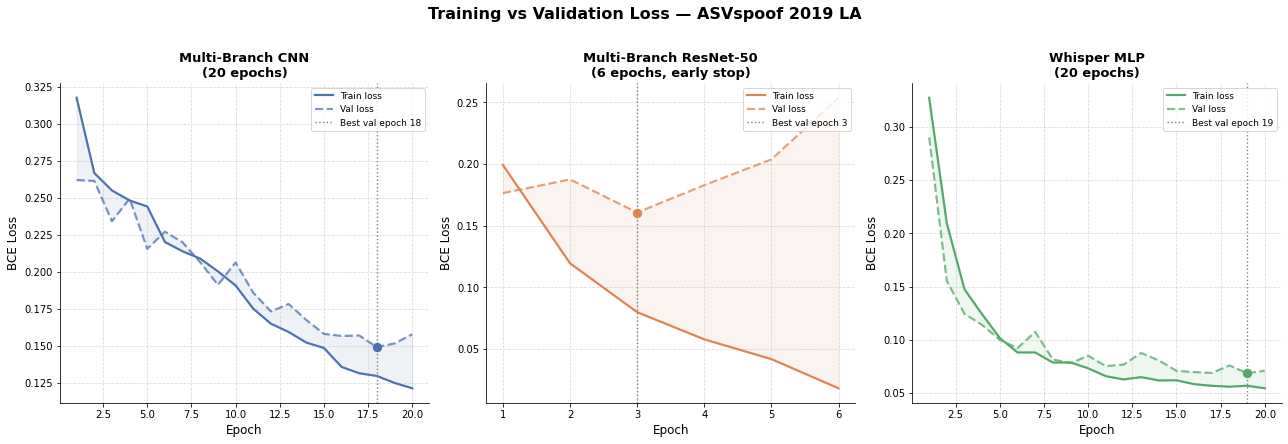

In [5]:
import pickle
import matplotlib.pyplot as plt

with open('saved_models/histories.pkl', 'rb') as f:
    hist = pickle.load(f)

cnn_h     = hist['cnn']
resnet_h  = hist['resnet']
whisper_h = hist['whisper']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Training vs Validation Loss — ASVspoof 2019 LA', fontsize=16, fontweight='bold', y=1.02)

configs = [
    (axes[0], cnn_h,    'Multi-Branch CNN\n(20 epochs)',               '#4C72B0'),
    (axes[1], resnet_h, 'Multi-Branch ResNet-50\n(6 epochs, early stop)', '#DD8452'),
    (axes[2], whisper_h,'Whisper MLP\n(20 epochs)',                    '#55A868'),
]
for ax, h, title, color in configs:
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], color=color, lw=2.2, label='Train loss')
    ax.plot(epochs, h['dev_loss'],   color=color, lw=2.2, linestyle='--', alpha=0.75, label='Val loss')
    ax.fill_between(epochs, h['train_loss'], h['dev_loss'], alpha=0.09, color=color)
    best_ep  = h['dev_loss'].index(min(h['dev_loss'])) + 1
    best_val = min(h['dev_loss'])
    ax.axvline(best_ep, color='gray', linestyle=':', lw=1.4, label=f'Best val epoch {best_ep}')
    ax.scatter([best_ep], [best_val], color=color, s=70, zorder=5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('BCE Loss', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.tick_params(labelsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig05_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

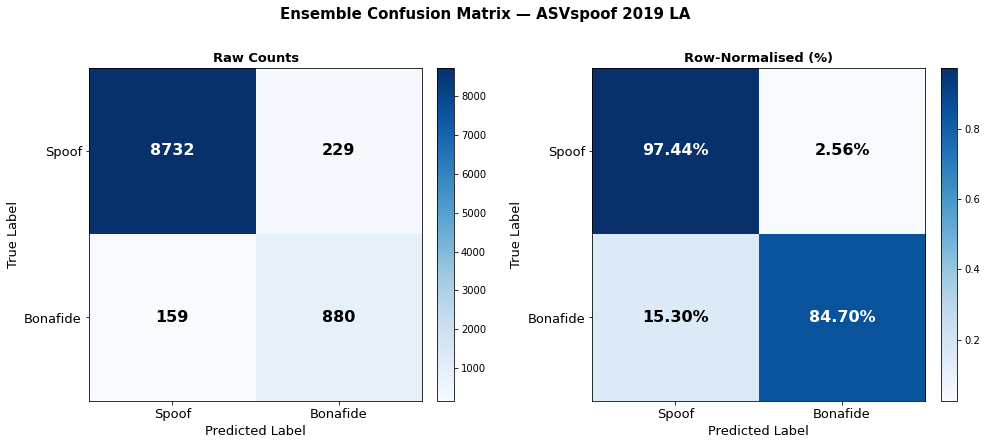

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

ens_probs   = np.load('saved_models/ensemble_probs.npy')
true_labels = np.load('saved_models/cnn_file_labels.npy')

pred_labels = (ens_probs > 0.5).astype(int)
cm      = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
class_names = ['Spoof', 'Bonafide']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Ensemble Confusion Matrix — ASVspoof 2019 LA ',
             fontsize=15, fontweight='bold', y=1.02)

for ax, data, title, fmt in [
    (axes[0], cm,      'Raw Counts',        'd'),
    (axes[1], cm_norm, 'Row-Normalised (%)', '.2%'),
]:
    im = ax.imshow(data, interpolation='nearest', cmap=plt.cm.Blues)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    thresh = data.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if data[i, j] > thresh else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(class_names, fontsize=13)
    ax.set_yticklabels(class_names, fontsize=13)
    ax.set_xlabel('Predicted Label', fontsize=13)
    ax.set_ylabel('True Label', fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig06_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

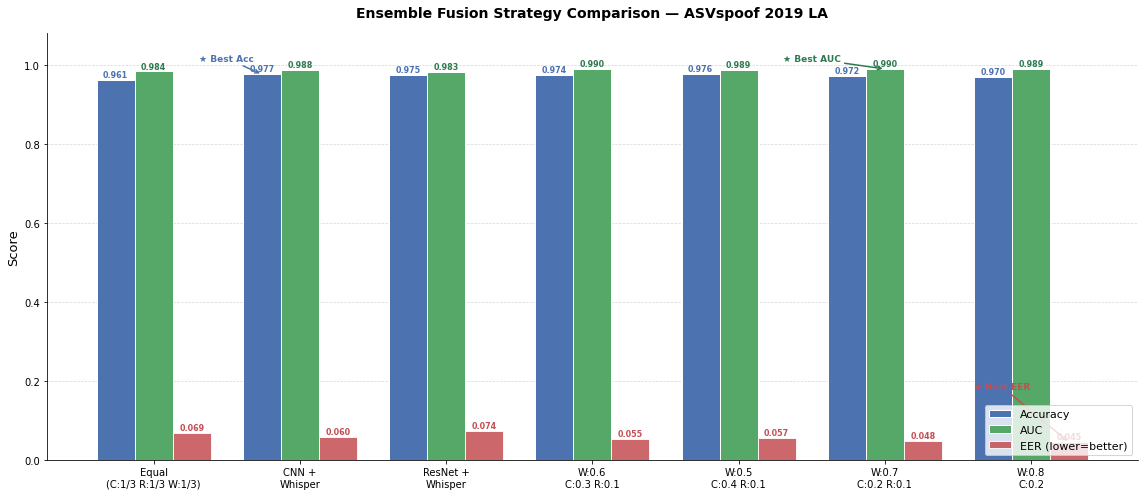

In [7]:
import numpy as np
import matplotlib.pyplot as plt

strategies = ['Equal\n(C:1/3 R:1/3 W:1/3)', 'CNN +\nWhisper', 'ResNet +\nWhisper',
              'W:0.6\nC:0.3 R:0.1', 'W:0.5\nC:0.4 R:0.1', 'W:0.7\nC:0.2 R:0.1', 'W:0.8\nC:0.2']
s_accs = [0.9612, 0.9766, 0.9746, 0.9736, 0.9763, 0.9717, 0.9699]
s_aucs = [0.9836, 0.9876, 0.9825, 0.9895, 0.9886, 0.9900, 0.9892]
s_eers = [0.0691, 0.0596, 0.0744, 0.0547, 0.0566, 0.0479, 0.0452]

x = np.arange(len(strategies))
width = 0.26

fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x-width, s_accs, width, label='Accuracy', color='#4C72B0', edgecolor='white', zorder=3)
b2 = ax.bar(x,        s_aucs, width, label='AUC',      color='#55A868', edgecolor='white', zorder=3)
b3 = ax.bar(x+width,  s_eers, width, label='EER (lower=better)', color='#C44E52', edgecolor='white', alpha=0.85, zorder=3)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for bar,val in zip(b1,s_accs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#4C72B0')
for bar,val in zip(b2,s_aucs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2d7a4f')
for bar,val in zip(b3,s_eers): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#C44E52')
ax.annotate('★ Best Acc', xy=(1-width, 0.9766), xytext=(0.5, 1.01), arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.5), ha='center', fontsize=9, color='#4C72B0', fontweight='bold')
ax.annotate('★ Best AUC', xy=(5, 0.9900),       xytext=(4.5, 1.01), arrowprops=dict(arrowstyle='->', color='#2d7a4f', lw=1.5), ha='center', fontsize=9, color='#2d7a4f', fontweight='bold')
ax.annotate('★ Best EER', xy=(6+width, 0.0452), xytext=(5.8, 0.18), arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5), ha='center', fontsize=9, color='#C44E52', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Ensemble Fusion Strategy Comparison — ASVspoof 2019 LA', fontsize=14, fontweight='bold', pad=16)
ax.legend(fontsize=11, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig07_ensemble_strategies.png', dpi=300, bbox_inches='tight')
plt.show()

## check it on unseen data

In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          CELL 1 — Imports                                        ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, io, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import whisper
from torchvision.models import resnet50, ResNet50_Weights
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    import pywt
except ImportError:
    os.system('pip install PyWavelets -q')
    import pywt

try:
    import librosa
except ImportError:
    os.system('pip install librosa -q')
    import librosa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(3)}')


# ╔══════════════════════════════════════════════════════════════════╗
# ║          CELL 2 — Model Definitions                              ║
# ╚══════════════════════════════════════════════════════════════════╝

class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Dropout2d(0.4),
            nn.Flatten()
        )
    def forward(self, x):
        return self.features(x)


class MultiBranchCNN(nn.Module):
    BRANCH_DIM = 128 * 8 * 8
    def __init__(self):
        super().__init__()
        self.stft_branch = CNNBranch()
        self.cqt_branch  = CNNBranch()
        self.wav_branch  = CNNBranch()
        self.classifier  = nn.Sequential(
            nn.Linear(self.BRANCH_DIM * 3, 512), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 256),                 nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )
    def forward(self, inputs):
        stft, cqt, wav = inputs
        return self.classifier(torch.cat([
            self.stft_branch(stft),
            self.cqt_branch(cqt),
            self.wav_branch(wav)
        ], dim=1))


class MultiBranchResNet(nn.Module):
    def __init__(self):
        super().__init__()
        def make_branch():
            m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
            m.fc = nn.Identity()
            return m
        self.stft_branch = make_branch()
        self.cqt_branch  = make_branch()
        self.wav_branch  = make_branch()
        self.classifier  = nn.Sequential(
            nn.Linear(2048 * 3, 512), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 256),      nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )
    def forward(self, inputs):
        stft, cqt, wav = inputs
        return self.classifier(torch.cat([
            self.stft_branch(stft),
            self.cqt_branch(cqt),
            self.wav_branch(wav)
        ], dim=1))


class WhisperMLP_Fast(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.mlp(x)

print('Model classes defined ✅')


# ╔══════════════════════════════════════════════════════════════════╗
# ║          CELL 3 — Load Weights                                   ║
# ╚══════════════════════════════════════════════════════════════════╝

SAVE_DIR = 'saved_models'   # ← change if your folder is elsewhere

cnn_model = MultiBranchCNN().to(device)
cnn_model.load_state_dict(torch.load(f'{SAVE_DIR}/best_cnn.pth', map_location=device))
cnn_model.eval()
print('✅ CNN loaded')

resnet_model = MultiBranchResNet().to(device)
resnet_model.load_state_dict(torch.load(f'{SAVE_DIR}/best_resnet50.pth', map_location=device))
resnet_model.eval()
print('✅ ResNet-50 loaded')

whisper_mlp = WhisperMLP_Fast().to(device)
whisper_mlp.load_state_dict(torch.load(f'{SAVE_DIR}/best_whisper_mlp.pth', map_location=device))
whisper_mlp.eval()
print('✅ Whisper MLP loaded')

print('Loading Whisper encoder (base)...')
whisper_model = whisper.load_model('base').to(device)
whisper_model.eval()
print('✅ Whisper encoder ready')


# ╔══════════════════════════════════════════════════════════════════╗
# ║          CELL 4 — Preprocessing Helpers                          ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── CELL 4 (corrected) — Preprocessing exactly matching training ──────

TARGET_SR      = 16000
SAMPLES_PER_SEG = TARGET_SR * 2   # 32000 samples = 2 seconds


def load_audio(file_bytes: bytes) -> torch.Tensor:
    buf = io.BytesIO(file_bytes)
    wav, sr = torchaudio.load(buf)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    return wav  # (1, T)


def segment_audio(waveform: torch.Tensor):
    """Split into 2-second segments, pad last if needed — identical to training."""
    segments = []
    total = waveform.shape[1]
    for start in range(0, total, SAMPLES_PER_SEG):
        seg = waveform[:, start:start + SAMPLES_PER_SEG]
        if seg.shape[1] < SAMPLES_PER_SEG:
            pad = SAMPLES_PER_SEG - seg.shape[1]
            seg = torch.nn.functional.pad(seg, (0, pad))
        segments.append(seg)
    return segments


def compute_stft(segment: torch.Tensor, sr=16000) -> np.ndarray:
    y = segment.numpy()[0]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=512, hop_length=128, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = librosa.util.fix_length(mel_db, size=64, axis=1)
    return mel_db[:64, :64]


def compute_cqt(segment: torch.Tensor, sr=16000) -> np.ndarray:
    y = segment.numpy()[0]
    cqt = np.abs(librosa.cqt(y=y, sr=sr, n_bins=64, hop_length=128))
    cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)
    cqt_db = librosa.util.fix_length(cqt_db, size=64, axis=1)
    return cqt_db[:64, :64]


def compute_wavelet(segment: torch.Tensor) -> np.ndarray:
    y = segment.numpy()[0]
    scales = np.arange(1, 65)
    coeffs, _ = pywt.cwt(y[:2048], scales, wavelet='mexh')   # ← mexh, first 2048 samples
    wav_spec = np.abs(coeffs)
    wav_spec = librosa.amplitude_to_db(wav_spec, ref=np.max)
    wav_spec = librosa.util.fix_length(wav_spec, size=64, axis=1)
    return wav_spec[:64, :64]


def make_tensor_with_delta(spec: np.ndarray) -> torch.Tensor:
    """Min-max normalize → delta → delta-delta → (3, 64, 64). Identical to training."""
    def normalize(s):
        s = s - s.min()
        if s.max() > 0:
            s = s / s.max()
        return s

    spec   = normalize(spec)
    delta  = normalize(librosa.feature.delta(spec))
    delta2 = normalize(librosa.feature.delta(spec, order=2))
    return torch.tensor(np.stack([spec, delta, delta2], axis=0), dtype=torch.float32)


def compute_all_tensors(segment: torch.Tensor, sr=16000):
    stft_t = make_tensor_with_delta(compute_stft(segment, sr))
    cqt_t  = make_tensor_with_delta(compute_cqt(segment, sr))
    wav_t  = make_tensor_with_delta(compute_wavelet(segment))
    return stft_t, cqt_t, wav_t


print('Preprocessing helpers ready ✅')

# ╔══════════════════════════════════════════════════════════════════╗
# ║          CELL 5 — Inference + Plot                               ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── CELL 5 (corrected) — Inference with segment averaging ─────────────

@torch.no_grad()
def predict_and_plot(file_bytes: bytes, filename: str):
    print(f'\n📂  File : {filename}')
    print('─' * 52)

    wav      = load_audio(file_bytes)
    duration = wav.shape[-1] / TARGET_SR
    segments = segment_audio(wav)
    print(f'    Duration : {duration:.2f} s  |  Segments : {len(segments)}')

    cnn_probs, res_probs, wh_probs = [], [], []

    # ── Whisper embedding (whole file, same as training pipeline) ──────
    print('⏳  Extracting Whisper embedding ...')
    y       = wav.squeeze(0).numpy()
    max_len = 30 * TARGET_SR
    y_pad   = y[:max_len] if len(y) > max_len else np.pad(y, (0, max_len - len(y)))
    mel_w   = whisper.log_mel_spectrogram(y_pad).to(device)
    with torch.no_grad():
        enc   = whisper_model.encoder(mel_w.unsqueeze(0))
        emb_t = enc.mean(dim=1).squeeze(0)              # (512,)
    wh_logit  = whisper_mlp(emb_t.unsqueeze(0).to(device)).item()
    wh_prob   = torch.sigmoid(torch.tensor(wh_logit)).item()

    # ── CNN + ResNet: run per segment, average ─────────────────────────
    print('⏳  Running CNN + ResNet on segments ...')
    for seg in segments:
        stft_t, cqt_t, wav_t = compute_all_tensors(seg)
        stft_t = stft_t.unsqueeze(0).to(device)
        cqt_t  = cqt_t.unsqueeze(0).to(device)
        wav_t  = wav_t.unsqueeze(0).to(device)

        cnn_probs.append(torch.sigmoid(cnn_model((stft_t, cqt_t, wav_t))).item())
        res_probs.append(torch.sigmoid(resnet_model((stft_t, cqt_t, wav_t))).item())

    cnn_prob = float(np.mean(cnn_probs))
    res_prob = float(np.mean(res_probs))
    ens_prob = (cnn_prob + res_prob + wh_prob) / 3

    results = {
        'CNN'        : cnn_prob,
        'ResNet-50'  : res_prob,
        'Whisper MLP': wh_prob,
        'Ensemble'   : ens_prob,
    }

    print('\n' + '═' * 52)
    print(f'  {"Model":<18}  {"P(bonafide)":>12}  {"Decision":>10}')
    print('─' * 52)
    for name, prob in results.items():
        label = '✅ BONAFIDE' if prob > 0.5 else '🚨 SPOOF'
        tag   = '  ◄ FINAL'  if name == 'Ensemble' else ''
        print(f'  {name:<18}  {prob:>12.4f}  {label:>10}{tag}')
    print('═' * 52)

    # Plot
    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    ax1    = fig.add_subplot(gs[0, 0])
    names  = list(results.keys())
    probs  = list(results.values())
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    bars   = ax1.barh(names, probs, color=colors, edgecolor='white')
    ax1.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
    ax1.set_xlim(0, 1)
    ax1.set_xlabel('P(bonafide)')
    ax1.set_title(f'Predictions — {filename}', fontweight='bold')
    for bar, val in zip(bars, probs):
        ax1.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)
    ax1.legend(fontsize=8)

    ax2 = fig.add_subplot(gs[0, 1])
    y   = wav.squeeze(0).numpy()
    t   = np.linspace(0, len(y) / TARGET_SR, len(y))
    ax2.plot(t, y, color='#4C72B0', linewidth=0.4, alpha=0.8)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude')
    ax2.set_title('Waveform', fontweight='bold')

    verdict = 'BONAFIDE ✅' if ens_prob > 0.5 else 'SPOOF 🚨'
    color   = 'green'       if ens_prob > 0.5 else 'red'
    fig.suptitle(f'Ensemble → {verdict}  (p={ens_prob:.4f})',
                 fontsize=14, fontweight='bold', color=color, y=1.02)
    plt.tight_layout()
    plt.show()

print('predict_and_plot() ready ✅')

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
Model classes defined ✅
✅ CNN loaded
✅ ResNet-50 loaded
✅ Whisper MLP loaded
Loading Whisper encoder (base)...
✅ Whisper encoder ready
Preprocessing helpers ready ✅
predict_and_plot() ready ✅


In [12]:
# ── paste this into its OWN separate cell and run it alone ──

uploader = widgets.FileUpload(
    accept='.wav,.flac,.mp3,.ogg,.m4a',
    multiple=False,
    description='Upload Audio',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

run_btn = widgets.Button(
    description='▶  Run Inference',
    button_style='success',
    layout=widgets.Layout(width='180px')
)

out = widgets.Output()


def on_run(_):
    with out:
        clear_output(wait=True)
        if not uploader.value:
            print('⚠️  Please upload an audio file first.')
            return

        val = uploader.value

        if isinstance(val, tuple):
            item = val[0]
        elif isinstance(val, dict):
            item = list(val.values())[0]
        else:
            item = val

        if isinstance(item, dict):
            fname   = item.get('name') or item.get('filename') or item.get('metadata', {}).get('name', 'audio')
            content = item.get('content') or item.get('data') or b''
        else:
            fname   = getattr(item, 'name', None) or getattr(item, 'filename', 'audio')
            content = getattr(item, 'content', None) or getattr(item, 'data', b'')

        print(f'📂 Detected file: {fname}  |  size: {len(bytes(content)):,} bytes')
        predict_and_plot(bytes(content), fname)


run_btn.on_click(on_run)

display(widgets.VBox([
    widgets.HTML('<h3>🎙️ Unseen Audio Tester</h3>'),
    widgets.HBox([uploader, run_btn]),
    out
]))

In [10]:
# ── CNN-only Test Cell ─────────────────────────────────────────────────

uploader_cnn = widgets.FileUpload(
    accept='.wav,.flac,.mp3,.ogg,.m4a',
    multiple=False,
    description='Upload Audio',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

run_btn_cnn = widgets.Button(
    description='▶  Test CNN',
    button_style='success',
    layout=widgets.Layout(width='160px')
)

out_cnn = widgets.Output()


@torch.no_grad()
def test_cnn(_):
    with out_cnn:
        clear_output(wait=True)
        if not uploader_cnn.value:
            print('⚠️  Please upload an audio file first.')
            return

        val  = uploader_cnn.value
        item = val[0] if isinstance(val, tuple) else list(val.values())[0]
        fname   = item.get('name') or item.get('metadata', {}).get('name', 'audio')
        content = item.get('content') or item.get('data') or b''

        print(f'📂  File : {fname}')
        print('─' * 50)

        wav      = load_audio(bytes(content))
        duration = wav.shape[-1] / TARGET_SR
        segments = segment_audio(wav)
        print(f'Duration  : {duration:.2f} s')
        print(f'Segments  : {len(segments)}')
        print()

        seg_probs = []
        for i, seg in enumerate(segments):
            stft_t, cqt_t, wav_t = compute_all_tensors(seg)
            stft_t = stft_t.unsqueeze(0).to(device)
            cqt_t  = cqt_t.unsqueeze(0).to(device)
            wav_t  = wav_t.unsqueeze(0).to(device)

            logit = cnn_model((stft_t, cqt_t, wav_t)).item()
            prob  = torch.sigmoid(torch.tensor(logit)).item()
            seg_probs.append(prob)
            print(f'  Seg {i+1:02d}  →  P(bonafide) = {prob:.4f}  {"✅" if prob > 0.5 else "🚨"}')

        final = float(np.mean(seg_probs))
        label = '✅ BONAFIDE' if final > 0.5 else '🚨 SPOOF'
        print()
        print('═' * 50)
        print(f'  CNN Final (avg)  →  {final:.4f}  {label}')
        print('═' * 50)

        # Plot per-segment probs
        plt.figure(figsize=(8, 4))
        plt.bar(range(1, len(seg_probs)+1), seg_probs,
                color=['#55A868' if p > 0.5 else '#C44E52' for p in seg_probs],
                edgecolor='white')
        plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
        plt.axhline(final, color='blue', linestyle='-', linewidth=1.5,
                    label=f'Average = {final:.4f}')
        plt.ylim(0, 1)
        plt.xlabel('Segment')
        plt.ylabel('P(bonafide)')
        plt.title(f'CNN — Per-Segment Probabilities\n{fname}', fontweight='bold')
        plt.legend()
        plt.tight_layout()
        plt.show()


run_btn_cnn.on_click(test_cnn)

display(widgets.VBox([
    widgets.HTML('<h3>🧪 CNN Model Test</h3>'),
    widgets.HBox([uploader_cnn, run_btn_cnn]),
    out_cnn
]))

In [11]:
# ── ResNet-50-only Test Cell ───────────────────────────────────────────

uploader_resnet = widgets.FileUpload(
    accept='.wav,.flac,.mp3,.ogg,.m4a',
    multiple=False,
    description='Upload Audio',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

run_btn_resnet = widgets.Button(
    description='▶  Test ResNet-50',
    button_style='success',
    layout=widgets.Layout(width='180px')
)

out_resnet = widgets.Output()


@torch.no_grad()
def test_resnet(_):
    with out_resnet:
        clear_output(wait=True)
        if not uploader_resnet.value:
            print('⚠️  Please upload an audio file first.')
            return

        val  = uploader_resnet.value
        item = val[0] if isinstance(val, tuple) else list(val.values())[0]
        fname   = item.get('name') or item.get('metadata', {}).get('name', 'audio')
        content = item.get('content') or item.get('data') or b''

        print(f'📂  File : {fname}')
        print('─' * 50)

        wav      = load_audio(bytes(content))
        duration = wav.shape[-1] / TARGET_SR
        segments = segment_audio(wav)
        print(f'Duration  : {duration:.2f} s')
        print(f'Segments  : {len(segments)}')
        print()

        seg_probs = []
        for i, seg in enumerate(segments):
            stft_t, cqt_t, wav_t = compute_all_tensors(seg)
            stft_t = stft_t.unsqueeze(0).to(device)
            cqt_t  = cqt_t.unsqueeze(0).to(device)
            wav_t  = wav_t.unsqueeze(0).to(device)

            logit = resnet_model((stft_t, cqt_t, wav_t)).item()
            prob  = torch.sigmoid(torch.tensor(logit)).item()
            seg_probs.append(prob)
            print(f'  Seg {i+1:02d}  →  P(bonafide) = {prob:.4f}  {"✅" if prob > 0.5 else "🚨"}')

        final = float(np.mean(seg_probs))
        label = '✅ BONAFIDE' if final > 0.5 else '🚨 SPOOF'
        print()
        print('═' * 50)
        print(f'  ResNet-50 Final (avg)  →  {final:.4f}  {label}')
        print('═' * 50)

        # Plot per-segment probs
        plt.figure(figsize=(8, 4))
        plt.bar(range(1, len(seg_probs)+1), seg_probs,
                color=['#55A868' if p > 0.5 else '#C44E52' for p in seg_probs],
                edgecolor='white')
        plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
        plt.axhline(final, color='blue', linestyle='-', linewidth=1.5,
                    label=f'Average = {final:.4f}')
        plt.ylim(0, 1)
        plt.xlabel('Segment')
        plt.ylabel('P(bonafide)')
        plt.title(f'ResNet-50 — Per-Segment Probabilities\n{fname}', fontweight='bold')
        plt.legend()
        plt.tight_layout()
        plt.show()


run_btn_resnet.on_click(test_resnet)

display(widgets.VBox([
    widgets.HTML('<h3>🧪 ResNet-50 Model Test</h3>'),
    widgets.HBox([uploader_resnet, run_btn_resnet]),
    out_resnet
]))

### classification table

In [15]:
# ── Classification Report — All Models ──
import numpy as np
from sklearn.metrics import classification_report

cnn_probs     = np.load('saved_models/cnn_file_probs.npy')
cnn_labels    = np.load('saved_models/cnn_file_labels.npy')
resnet_probs  = np.load('saved_models/resnet_file_probs.npy')
whisper_probs = np.load('saved_models/whisper_probs.npy')
whisper_lbls  = np.load('saved_models/whisper_labels.npy')
ens_probs     = np.load('saved_models/ensemble_probs.npy')

cnn_preds     = (cnn_probs    > 0.5).astype(int)
resnet_preds  = (resnet_probs > 0.5).astype(int)
whisper_preds = (whisper_probs> 0.5).astype(int)
ens_preds     = (ens_probs    > 0.5).astype(int)

models = {
    'Multi-Branch CNN'              : (cnn_labels,    cnn_preds),
    'Multi-Branch ResNet-50'        : (cnn_labels,    resnet_preds),
    'Whisper MLP'                   : (whisper_lbls,  whisper_preds),
    'Ensemble (CNN+ResNet+Whisper)' : (cnn_labels,    ens_preds),
}

for name, (labels, preds) in models.items():
    print('═'*55)
    print(f'  {name}')
    print('═'*55)
    print(classification_report(labels, preds,
                                 target_names=['Spoof','Bonafide'],
                                 digits=4))

═══════════════════════════════════════════════════════
  Multi-Branch CNN
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

       Spoof     0.9713    0.9018    0.9352      8961
    Bonafide     0.4762    0.7700    0.5885      1039

    accuracy                         0.8881     10000
   macro avg     0.7237    0.8359    0.7618     10000
weighted avg     0.9198    0.8881    0.8992     10000

═══════════════════════════════════════════════════════
  Multi-Branch ResNet-50
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

       Spoof     0.9730    0.8443    0.9041      8961
    Bonafide     0.3728    0.7979    0.5081      1039

    accuracy                         0.8395     10000
   macro avg     0.6729    0.8211    0.7061     10000
weighted avg     0.9106    0.8395    0.8630     10000

═══════════════════════════════════════════════════════
  Whisper MLP
════════